### 1. Import the necessary libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline 
import seaborn as sns

 
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

In [2]:
# This is done to make Jupyter show all the columns. Otherwise Jupyter hides columns
pd.set_option('max_columns', None)

### 2. Import data 2C_weka.csv for 2 Class Classification.

In [3]:
# 2. Import data 2C_weka.csv for 2 Class Classification.

missing_value_formats = ["n.a.","?","NA","n/a","na","--"," ", "  "]
TwoC_weka_data = pd.read_csv('2Classdata.csv', na_values = missing_value_formats)

### 3. Explore the dataset and mention the insights

In [5]:
TwoC_weka_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 310 entries, 0 to 309
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   pelvic_incidence          310 non-null    float64
 1   pelvic_tilt numeric       310 non-null    float64
 2   lumbar_lordosis_angle     310 non-null    float64
 3   sacral_slope              310 non-null    float64
 4   pelvic_radius             310 non-null    float64
 5   degree_spondylolisthesis  310 non-null    float64
 6   class                     310 non-null    object 
dtypes: float64(6), object(1)
memory usage: 17.1+ KB


In [5]:
# There are 6 columns. 5 are of type numerical & 1 categorical

In [6]:
TwoC_weka_data.describe()

,pelvic_incidence,pelvic_tilt numeric,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis
count,310.000000,310.000000,310.000000,310.000000,310.000000,310.000000
mean,60.496653,17.542822,51.930930,42.953831,117.920655,26.296694
std,17.236520,10.008330,18.554064,13.423102,13.317377,37.559027
min,26.147921,-6.554948,14.000000,13.366931,70.082575,-11.058179
25%,46.430294,10.667069,37.000000,33.347122,110.709196,1.603727
50%,58.691038,16.357689,49.562398,42.404912,118.268178,11.767934
75%,72.877696,22.120395,63.000000,52.695888,125.467674,41.287352
max,129.834041,49.431864,125.742385,121.429566,163.071041,418.543082


In [13]:
# Except "degree_spondylolisthesis", rest all of the columns have distribution close to normal. degree_spondylolisthesis seems to be
# right-tailed or positively skewed. 

In [7]:
TwoC_weka_data.shape

(310, 7)

In [15]:
# The 2C_weka has 310 rows & 7 columns

In [8]:
# Checking top 5 rows
TwoC_weka_data.head()

,pelvic_incidence,pelvic_tilt numeric,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,class
0,63.027818,22.552586,39.609117,40.475232,98.672917,-0.254400,Abnormal
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,Abnormal
2,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317,Abnormal
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523,Abnormal
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,Abnormal


In [9]:
# Checking last 5 rows
TwoC_weka_data.tail()

,pelvic_incidence,pelvic_tilt numeric,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,class
305,47.903565,13.616688,36.000000,34.286877,117.449062,-4.245395,Normal
306,53.936748,20.721496,29.220534,33.215251,114.365845,-0.421010,Normal
307,61.446597,22.694968,46.170347,38.751628,125.670725,-2.707880,Normal
308,45.252792,8.693157,41.583126,36.559635,118.545842,0.214750,Normal
309,33.841641,5.073991,36.641233,28.767649,123.945244,-0.199249,Normal


In [10]:
# Checking for skewness
TwoC_weka_data.skew()

pelvic_incidence            0.520440
pelvic_tilt numeric         0.676553
lumbar_lordosis_angle       0.599451
sacral_slope                0.792577
pelvic_radius              -0.176835
degree_spondylolisthesis    4.317954
dtype: float64

In [49]:
# As mentioned above "degree_spondylolisthesis" is positively skewed. 

In [36]:
TwoC_weka_data.isna().sum()

pelvic_incidence            0
pelvic_tilt numeric         0
lumbar_lordosis_angle       0
sacral_slope                0
pelvic_radius               0
degree_spondylolisthesis    0
class                       0
dtype: int64

In [37]:
TwoC_weka_data.isnull().sum()

pelvic_incidence            0
pelvic_tilt numeric         0
lumbar_lordosis_angle       0
sacral_slope                0
pelvic_radius               0
degree_spondylolisthesis    0
class                       0
dtype: int64

In [38]:
TwoC_weka_data.duplicated().sum()

0

In [ ]:
# There are no null values and there is no duplicate data.

#### Univariate Analysis

In [39]:
# Checking for unique value count in target variable "class"

In [4]:
print(TwoC_weka_data['class'].unique())

['Abnormal' 'Normal']


In [5]:
# So, there are two classes  'Abnormal' & 'Normal'

In [ ]:
# Count of each class

In [6]:
# Method 1
pd.crosstab(TwoC_weka_data['class'],columns='Count')

col_0,Count
class,
Abnormal,210
Normal,100


In [8]:
# Method 2
print(TwoC_weka_data['class'].value_counts())

Abnormal    210
Normal      100
Name: class, dtype: int64


<AxesSubplot:xlabel='class', ylabel='count'>

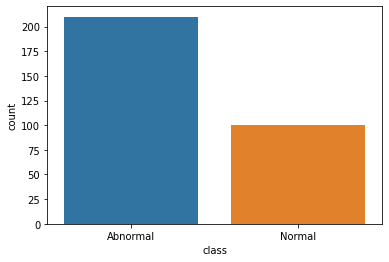

In [10]:
# Method 3
sns.countplot(x='class',data=TwoC_weka_data)

In [22]:
# Records for Abnormal crlass is more than Normal class

In [10]:
# Identifying Type Of Features 
# Numerical Features & Categorical Features

numerical_features = TwoC_weka_data.select_dtypes(include = [np.number])

In [11]:
print(numerical_features.columns)

Index(['pelvic_incidence', 'pelvic_tilt numeric', 'lumbar_lordosis_angle',
       'sacral_slope', 'pelvic_radius', 'degree_spondylolisthesis'],
      dtype='object')


In [ ]:
# Now we want to segregate discrete variables from continuous variables
# So, we count the number of unique values in each feature. If count of unique values is less than 25 then we consider it as
# discrete variable otherwise it is a continuous variable

In [12]:
continuous_numerical_features = []
discrete_numerical_features = []

In [13]:
for feature in numerical_features:
    if(len(TwoC_weka_data[feature].unique())>25):
        continuous_numerical_features.append(feature)
        print('continuous_numerical_features ',feature)
   

continuous_numerical_features  pelvic_incidence
continuous_numerical_features  pelvic_tilt numeric
continuous_numerical_features  lumbar_lordosis_angle
continuous_numerical_features  sacral_slope
continuous_numerical_features  pelvic_radius
continuous_numerical_features  degree_spondylolisthesis


In [ ]:
# This shows that all the features are continuous 

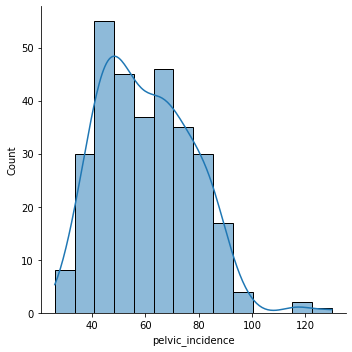

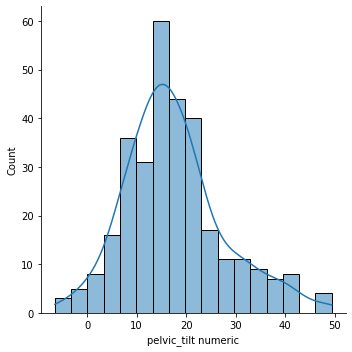

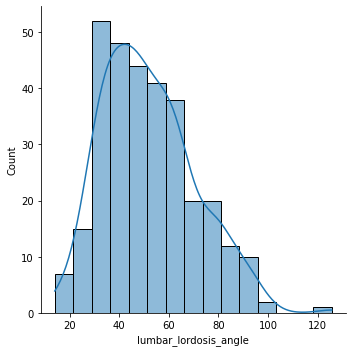

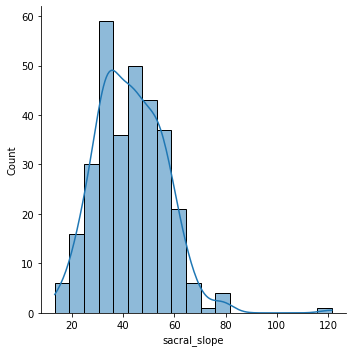

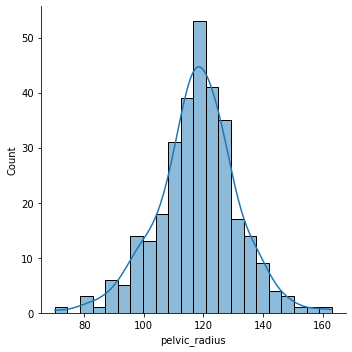

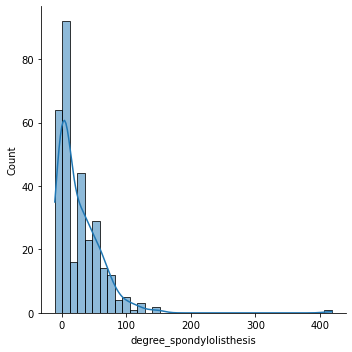

In [13]:
# Visualizing Distribution For Numerical Columns
# Not using distplot as it is going to be deprecated. See below link 
# https://seaborn.pydata.org/generated/seaborn.distplot.html?highlight=distplot#seaborn.distplot

for feature in numerical_features.columns:
    sns.displot(numerical_features[feature],kde=True)
    plt.show()

In [14]:
# Features "pelvic_tilt" & "pelvic_radius"  are very close to normal. 
# Features "pelvic_incidence", "lumbar_lordosis_angle" & "sacral_slope" have some kind of uniform distribution.
# Feature degree_spondylolisthesis is highly positively skewed.

In [ ]:
# Now looking for IQR & Outliers

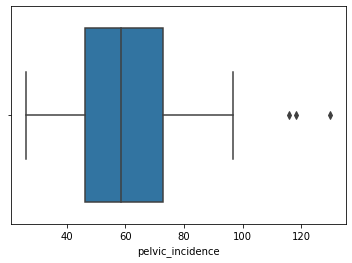

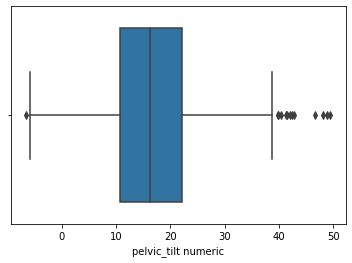

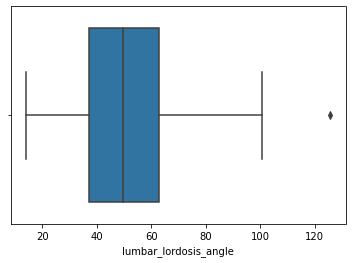

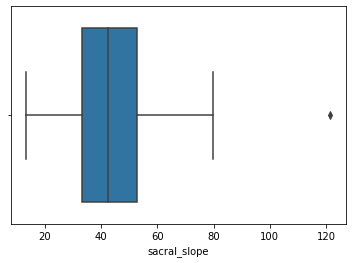

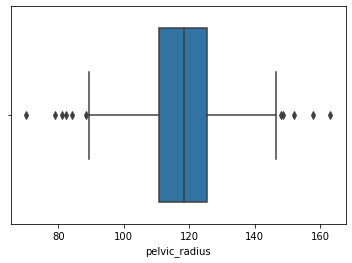

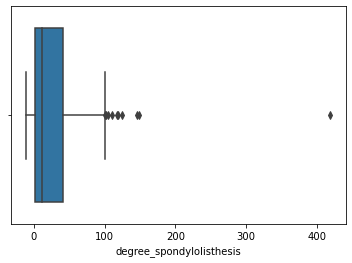

In [15]:
for feature in numerical_features.columns:
    sns.boxplot(TwoC_weka_data[feature])
    plt.show()

In [ ]:
# There are outliers in all of the features. Features "lumbar_lordosis_angle" & "sacral_slope" have just one outlier.
# Rest all have many outlies

#### Bivariate Analysis

<AxesSubplot:>

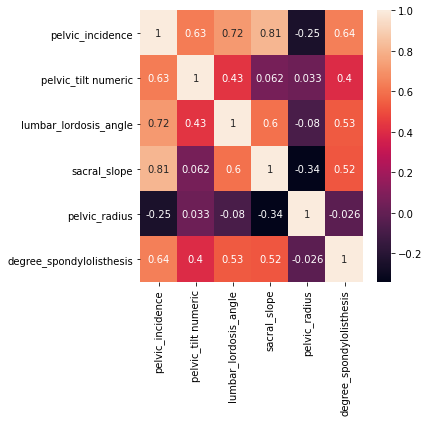

In [17]:
# Plotting Correlation HeatMap

plt.figure(figsize=(5,5))
sns.heatmap(TwoC_weka_data.corr(),annot=True)

In [ ]:
# It looks like there is some multicolinearity here. For example: Feature "pelvic_incidence" seems to be correlated with all the other features except "pelvic_radius".

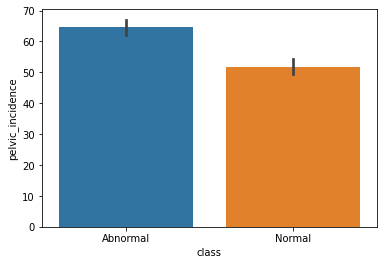

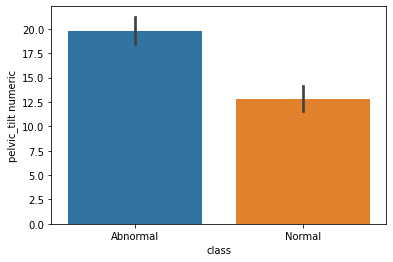

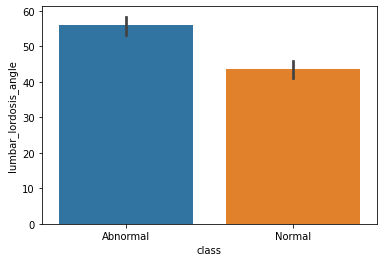

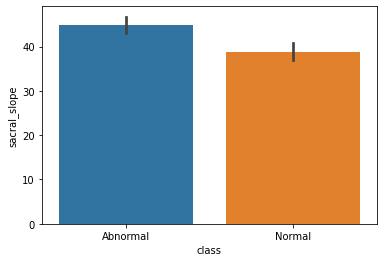

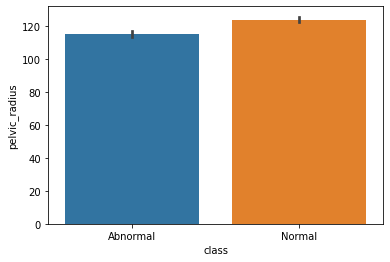

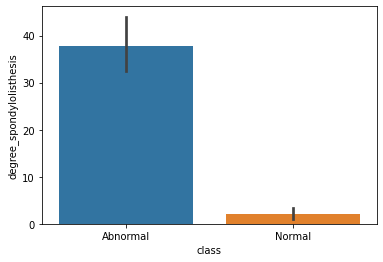

In [18]:
# Barplot showing the numbers

for feature in numerical_features.columns:
    sns.barplot(x='class',y=feature,data=TwoC_weka_data)
    plt.show()

In [20]:
# Class "Abnormal" has more count as compare to Normal for alsmot all of the features

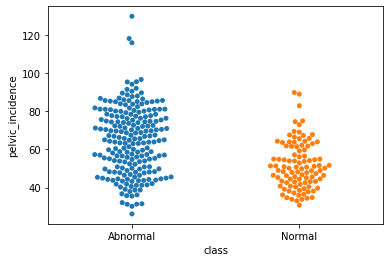

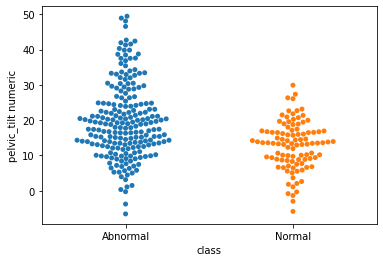

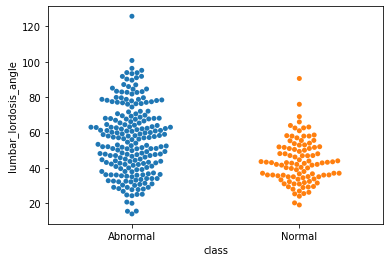

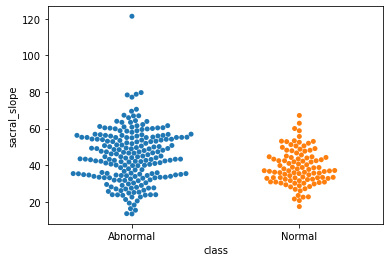

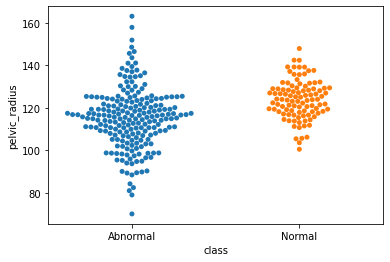

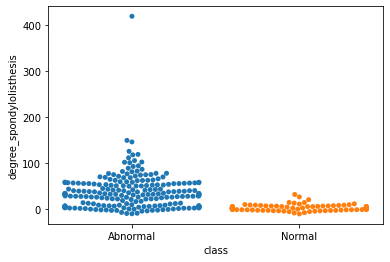

In [21]:
# Plotting swarmplot as target feature is categorical

for feature in numerical_features.columns:
    sns.swarmplot(TwoC_weka_data['class'],TwoC_weka_data[feature])
    plt.show()

In [ ]:
# Swarmplot shows distributon of each feature for both the classes. 

# For pelvic_incidence, majority of abnormal class points clustered between 40 & 95
# For pelvic_tilt numeric, majority of abnormal class points clustered between 10 & 25
# For lumbar_lordosis_angle, majority of abnormal class points clustered between 35 & 80
# For sacral_slope, majority of abnormal class points clustered between 40 & 60
# For pelvic_radius, majority of abnormal class points clustered between 100 & 130
 

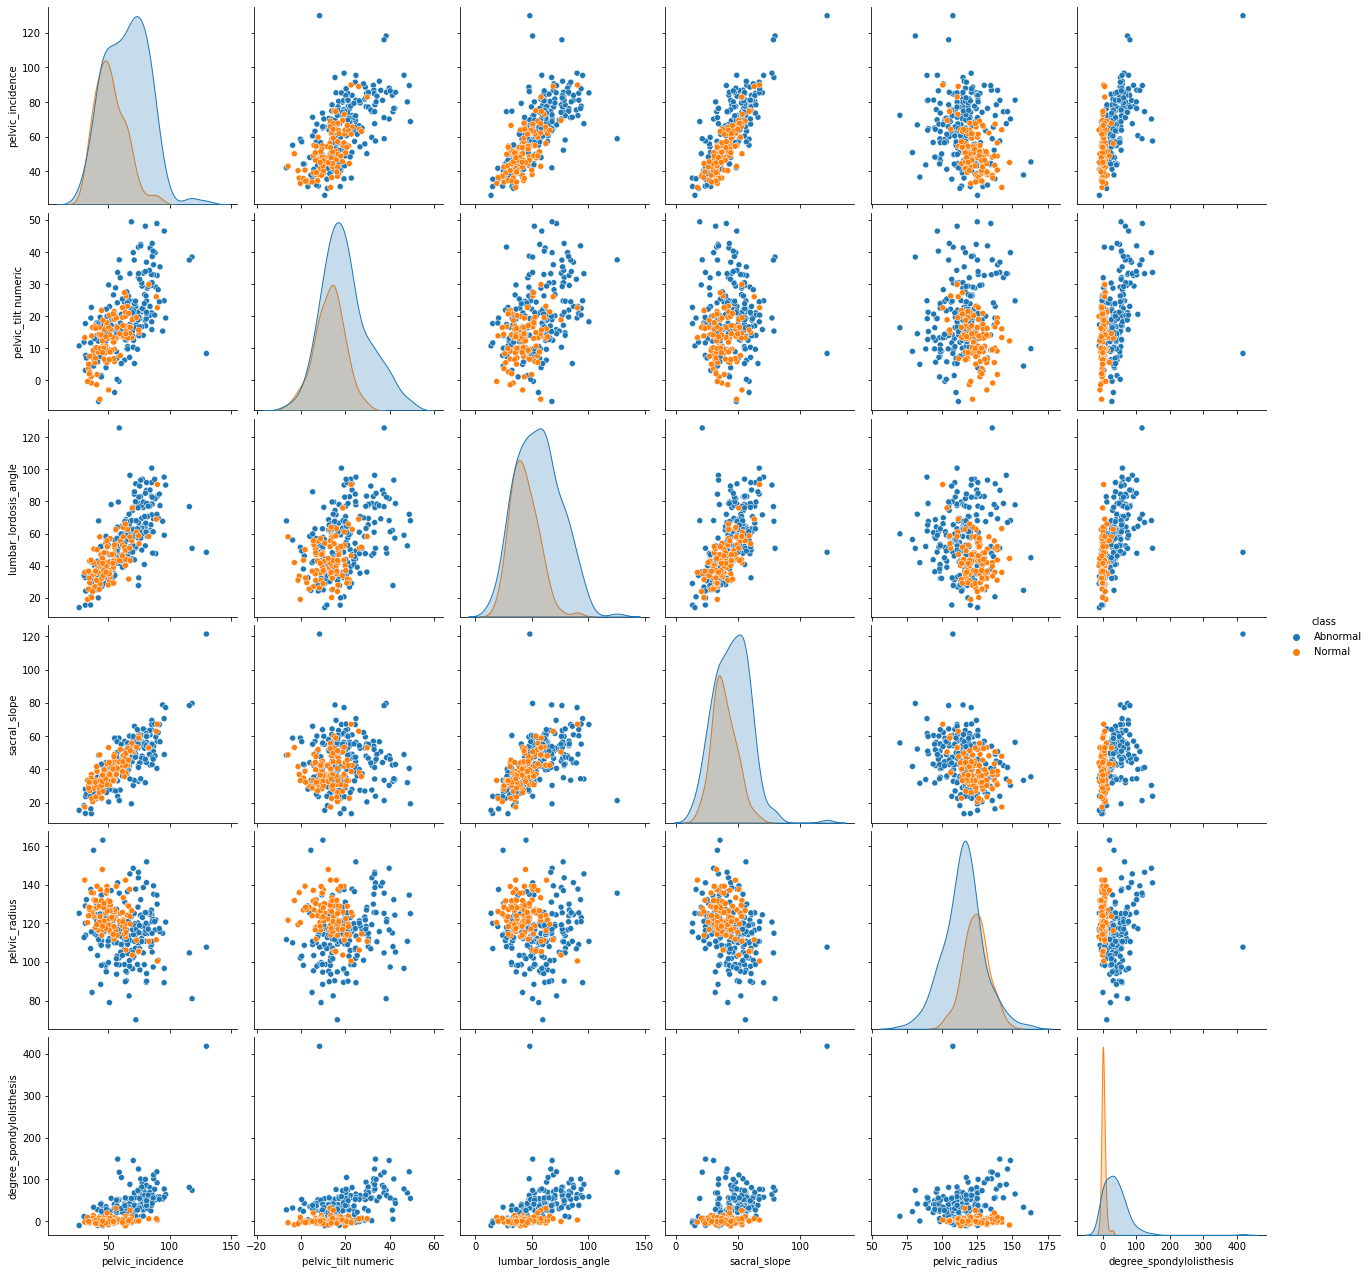

In [15]:
# Plotting pairplot
sns.pairplot(TwoC_weka_data,size=3,hue='class')

In [ ]:
# There seems to be good separation between normal and abnormal for all the features except "degree_spondylolisthesis" as it is 
# highly skewed. Good separation indicates that, that particular feature could be a good indicator. 
# There seems like the independent features have some kind of relation. 
# For example: Feature 'pelvic_incidence' seems linearly related to 'pelvic_tilt_numeric' & 'lumbar_lordosis_angle' & 'sacral_slope'

In [14]:
# Fetching categorical variables
categorical_features = TwoC_weka_data.select_dtypes(exclude = [np.number])

### 4. Encode the Class variable to integer

In [16]:
lbc = LabelEncoder()
TwoC_weka_data_encoded = TwoC_weka_data.copy()

In [31]:
for feature in categorical_features:
    TwoC_weka_data_encoded[feature] =  lbc.fit_transform(TwoC_weka_data[feature])

In [13]:
TwoC_weka_data_encoded 

,pelvic_incidence,pelvic_tilt numeric,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,class
0,63.027818,22.552586,39.609117,40.475232,98.672917,-0.254400,0
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,0
2,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317,0
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523,0
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,0
...,...,...,...,...,...,...,...
305,47.903565,13.616688,36.000000,34.286877,117.449062,-4.245395,1
306,53.936748,20.721496,29.220534,33.215251,114.365845,-0.421010,1
307,61.446597,22.694968,46.170347,38.751628,125.670725,-2.707880,1
308,45.252792,8.693157,41.583126,36.559635,118.545842,0.214750,1


In [14]:
TwoC_weka_data

,pelvic_incidence,pelvic_tilt numeric,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,class
0,63.027818,22.552586,39.609117,40.475232,98.672917,-0.254400,Abnormal
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,Abnormal
2,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317,Abnormal
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523,Abnormal
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,Abnormal
...,...,...,...,...,...,...,...
305,47.903565,13.616688,36.000000,34.286877,117.449062,-4.245395,Normal
306,53.936748,20.721496,29.220534,33.215251,114.365845,-0.421010,Normal
307,61.446597,22.694968,46.170347,38.751628,125.670725,-2.707880,Normal
308,45.252792,8.693157,41.583126,36.559635,118.545842,0.214750,Normal


In [74]:
# I have used Scikit Learn's Label Encoder function above for the assignment purpose but the issue with it is, it encodes classes in "alphabetical order". 
# In our case, as you can see above, it encoded Abnormal as 0 & Normal as 1 because "N" of Normal comes after "A" of Abnormal
# I wanted to have Normal as 0 & Abnormal as 1. I tried set_params method & googled about it but I could not get the desired result.
# So, to get the encoding I want, I am using simple pandas map function to go ahead with model training.

In [16]:
TwoC_weka_data_encoded['class'] =TwoC_weka_data_encoded['class'].map({'Normal':0, 'Abnormal':1 })

In [17]:
TwoC_weka_data_encoded

,pelvic_incidence,pelvic_tilt numeric,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,class
0,63.027818,22.552586,39.609117,40.475232,98.672917,-0.254400,1
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,1
2,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317,1
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523,1
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,1
...,...,...,...,...,...,...,...
305,47.903565,13.616688,36.000000,34.286877,117.449062,-4.245395,0
306,53.936748,20.721496,29.220534,33.215251,114.365845,-0.421010,0
307,61.446597,22.694968,46.170347,38.751628,125.670725,-2.707880,0
308,45.252792,8.693157,41.583126,36.559635,118.545842,0.214750,0


In [ ]:
# Now, we got the desired encoding.
# But, I am not going to use this encoding either.
# Reason is, in classification report, I want to print "Abnormal & Normal" instead of 0 & 1 which is easy to understand. 

In [17]:
# Power Transformation is done to make data normal.
# Creating a dataset of numerical features only for transformation

numerical_dataset = TwoC_weka_data_encoded.iloc[:,:6]
numerical_dataset

,pelvic_incidence,pelvic_tilt numeric,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis
0,63.027818,22.552586,39.609117,40.475232,98.672917,-0.254400
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259
2,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501
...,...,...,...,...,...,...
305,47.903565,13.616688,36.000000,34.286877,117.449062,-4.245395
306,53.936748,20.721496,29.220534,33.215251,114.365845,-0.421010
307,61.446597,22.694968,46.170347,38.751628,125.670725,-2.707880
308,45.252792,8.693157,41.583126,36.559635,118.545842,0.214750


In [18]:
power = PowerTransformer(method='yeo-johnson', standardize=True)
TwoC_weka_data_transformed = power.fit_transform(numerical_dataset)
TwoC_weka_data_transformed = pd.DataFrame(TwoC_weka_data_transformed,columns = numerical_dataset.columns)

In [19]:
TwoC_weka_data_transformed.head()

,pelvic_incidence,pelvic_tilt numeric,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis
0,0.257617,0.534531,-0.603254,-0.099794,-1.426465,-0.789163
1,-1.356466,-0.714095,-1.694145,-1.071028,-0.289648,-0.443516
2,0.572348,0.502944,0.020947,0.355733,-0.907444,-1.339499
3,0.596634,0.731407,-0.310979,0.213504,-1.201685,-0.155518
4,-0.562700,-0.758142,-1.416026,-0.131921,-0.749270,-0.286411


             Original  pelvic_incidence


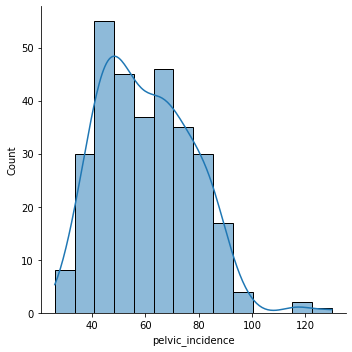

             Transformed  pelvic_incidence


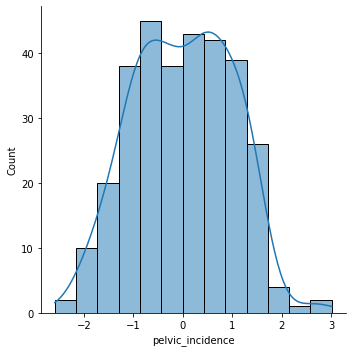

-----------------------------------------------------
             Original  pelvic_tilt numeric


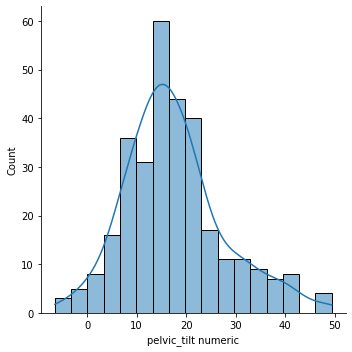

             Transformed  pelvic_tilt numeric


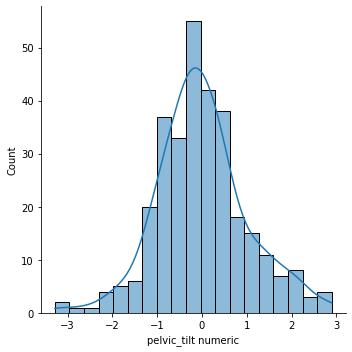

-----------------------------------------------------
             Original  lumbar_lordosis_angle


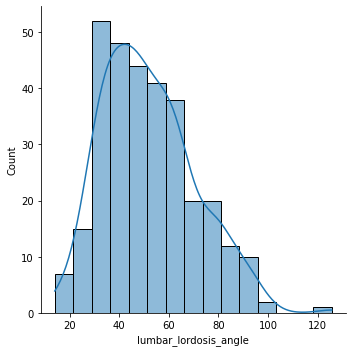

             Transformed  lumbar_lordosis_angle


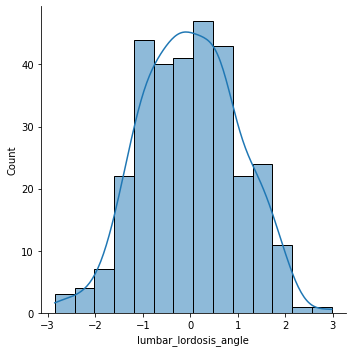

-----------------------------------------------------
             Original  sacral_slope


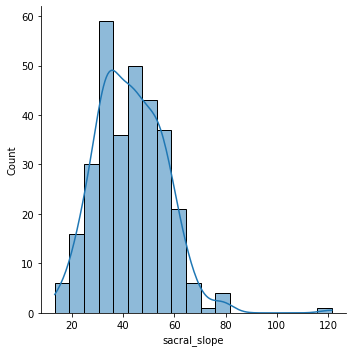

             Transformed  sacral_slope


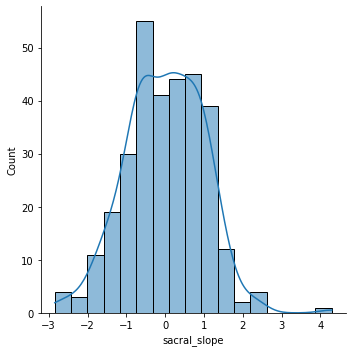

-----------------------------------------------------
             Original  pelvic_radius


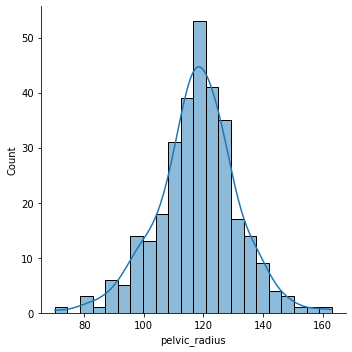

             Transformed  pelvic_radius


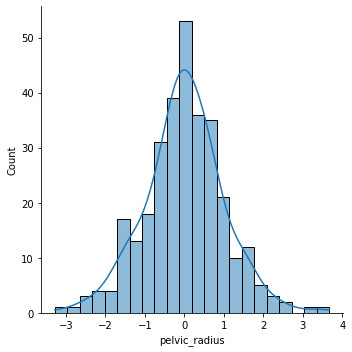

-----------------------------------------------------
             Original  degree_spondylolisthesis


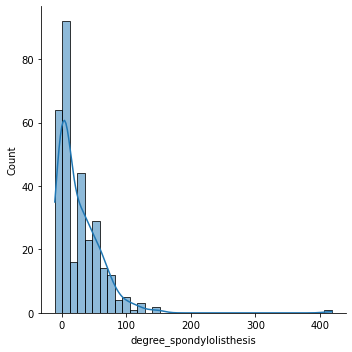

             Transformed  degree_spondylolisthesis


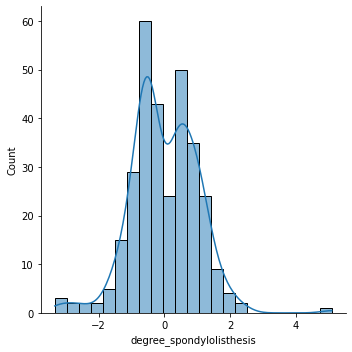

-----------------------------------------------------


In [20]:
# Distribution after transformation. 
# I have plotted both the original & transformed distribution for comparison.
# We can observe that features have been transformed into Normal distribution

for feature in TwoC_weka_data_transformed.columns:
    print("             Original ", feature)
    sns.displot(numerical_features[feature],kde=True)
    plt.show()
    print("             Transformed ", feature)
    sns.displot(TwoC_weka_data_transformed[feature],kde=True)
    plt.show()  
    print("-----------------------------------------------------")

In [58]:
# Now, this feature "degree_spondylolisthesis" shown above is not fully normal. It has two peaks. At this stage of this course, what I know is
# we separate these two peaks then we move forward. But we haven't completed such topic so far. So, I will keep this as it is.

### 5. Create the X(Feature-set) and Y(Target-set) sets for your Data

In [21]:
# Keeping X in uppercase & y in lowercase as per standard convention

X = TwoC_weka_data_transformed
y = TwoC_weka_data.iloc[:,6:]

### 7. Split the data as a train and test with a ratio of 70:30
### 6. Normalize your Data (X) to get values between 0 to 1
### 8. Train k-NN algorithm and optionally one other classification algorithm of your choice using the train data and measure their accuracy scores on the test data

In [25]:
# 8. Training KNN algorithm


# K-neighbours Classifier

# First Splitting the data set into train & test data set so that while scaling or normalizing, test data should not affect train data
# Second, different random states can give different results. So we need to test for multiple random states
# Third, for every random state, different value of k can give different results. So, we need to test for multiple values of k
# for each of the random state

# fit gives you mean and standard deviation
# So we do "fit" the model using train data and then "transform" or apply that mean & std on test data.

# Scaling should be done separately on train data & test data. Data leak issue occurs.
# It may show higher accuracy but might not be true
# Scaling or Normalization
# This is done to scale or normalize all the variable with different scales so that all these variable become comparable. 
# Compare Km/Hr to Mtr/Sec

# We check for multiple random state & for each random state, we check for multiple K values
# This is how we can come to a conclusion which random state and value of K is to be chosen
# We can also change the metric & weights as we find appropriate
# We can apply any condition we like


ran_state = np.arange(1,50)
neighbours = np.arange(5,41) 
# I know that it is better to keep K-Value odd to have clear majority but I am not keeping it because I tried and I am getting much 
# better result with even numbers.

 
test_accuracy_list = []
train_accuracy_list = []
desired_k_value_list = []
desired_random_state_list = []
conf_matrix_report_list = []
class_report_list = []
 

for r_state in ran_state:
    # 7. Split the data as a train and test with a ratio of 70:30
    X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=r_state)
    
    std_scaler = StandardScaler() 
    # 6. Normalize your Data (X)
    std_scaler.fit(X_train)     
    X_train_scaled = std_scaler.transform(X_train)
    X_test_scaled  = std_scaler.transform(X_test)
    
    for k_value in neighbours:
        # For metric='minkowski' p=2 means using Euclidean distance &  p=1 means Manhattan distance 
        KNN = KNeighborsClassifier(n_neighbors=k_value,metric='minkowski',algorithm='auto',p=2) 
        
        KNN.fit(X_train_scaled,y_train)
        y_pred = KNN.predict(X_test_scaled)    
        
        conf_matrix = metrics.confusion_matrix(y_test,y_pred)
        class_report = metrics.classification_report(y_test,y_pred)
        train_score = np.round(KNN.score(X_train_scaled,y_train),2)
        test_score = np.round(KNN.score(X_test_scaled,y_test),2)
        test_accuracy_list.append(test_score)
        train_accuracy_list.append(train_score)
        desired_k_value_list.append(k_value)
        desired_random_state_list.append(r_state)
        conf_matrix_report_list.append(conf_matrix)
        class_report_list.append(class_report)

        
test_accuracy_array = np.array(test_accuracy_list)
result = np.where(test_accuracy_array>0.85)
result = result[0]

     # If a patient is predicted Normal when he is Abnormal, then this prediction is bad. Patient is having medical issue but model 
     # predicted patient does not have any issue. We definitely need to minimize this (False Negative) as much as possible. So, I have chosen conf_matrix[1,0]<5 
     # for the this reason.
    
for r in result:  
    conf = conf_matrix_report_list[r]
    if(conf[1,0]<5):
        print('Test Accuracy',test_accuracy_list[r],'Train Accuracy',train_accuracy_list[r],'K Value ' ,desired_k_value_list[r],'Random State ',desired_random_state_list[r])
        print()
        print("Confusion Matrix ")
        print(conf_matrix_report_list[r])
        print()
        print("Classification Report ")
        print(class_report_list[r])
        print("--------------------------------------------------------")

        

Test Accuracy 0.87 Train Accuracy 0.84 K Value  13 Random State  3

Confusion Matrix 
[[57  9]
 [ 3 24]]

Classification Report 
              precision    recall  f1-score   support

    Abnormal       0.95      0.86      0.90        66
      Normal       0.73      0.89      0.80        27

    accuracy                           0.87        93
   macro avg       0.84      0.88      0.85        93
weighted avg       0.89      0.87      0.87        93

--------------------------------------------------------
Test Accuracy 0.87 Train Accuracy 0.83 K Value  15 Random State  3

Confusion Matrix 
[[58  8]
 [ 4 23]]

Classification Report 
              precision    recall  f1-score   support

    Abnormal       0.94      0.88      0.91        66
      Normal       0.74      0.85      0.79        27

    accuracy                           0.87        93
   macro avg       0.84      0.87      0.85        93
weighted avg       0.88      0.87      0.87        93

-------------------------------

### 9. What is the best K value for your classification? Find at which k value you get the best score

In [23]:
# Here, as per my understanding, keeping False Negative as much low as possible should be on priority keeping test accuracy high so, Random State 3 & K - Value = 13
# gives us overall test accuracy 87, precision for Abnormal class 95 & false negative = 3 which is the minimum we got for KNN. 

In [194]:
# Training Gaussian Naive Bayes

ran_state = np.arange(1,50)

test_accuracy_list = []
train_accuracy_list = []
desired_random_state_list = []
conf_matrix_report_list = []
class_report_list = []

for r_state in ran_state:
    GNB_X_train,GNB_X_test,GNB_y_train,GNB_y_test = train_test_split(X,y,test_size=0.3,random_state=r_state)
    
    gnb = GaussianNB()
    gnb.fit(GNB_X_train,GNB_y_train)
    GNB_y_pred = gnb.predict(GNB_X_test)
    
    conf_matrix = metrics.confusion_matrix(GNB_y_test,GNB_y_pred)
    class_report = metrics.classification_report(GNB_y_test,GNB_y_pred)
    test_score = np.round(gnb.score(GNB_X_test,GNB_y_test),2)
    train_score = np.round(gnb.score(GNB_X_train,GNB_y_train),2)
    test_accuracy_list.append(test_score)
    train_accuracy_list.append(train_score)   
    desired_random_state_list.append(r_state)
    conf_matrix_report_list.append(conf_matrix)
    class_report_list.append(class_report)
        
       
     # If a patient is predicted Normal when he is Abnormal, then this prediction is bad. Patient is having medical issue but model 
     # predicted patient does not have any issue. We definitely need to minimize this (False Negative) as much as possible. 
     # I have chosen conf_matrix[1,0]<5 just to minimize result printing & to avoid unecessary scrolling notebook.
        
test_accuracy_array = np.array(test_accuracy_list)
result = np.where(test_accuracy_array>0.80)
result = result[0]


for r in result:
    conf = conf_matrix_report_list[r]
    if(conf[1,0]<5):
        print('Test Accuracy',test_accuracy_list[r],'Train Accuracy',train_accuracy_list[r],'Random State ',desired_random_state_list[r])
        print()
        print("Confusion Matrix ")
        print(conf_matrix_report_list[r])
        print()
        print("Classification Report ")
        print(class_report_list[r])
        print("--------------------------------------------------------")
    
  


Test Accuracy 0.81 Train Accuracy 0.78 Random State  2

Confusion Matrix 
[[54 14]
 [ 4 21]]

Classification Report 
              precision    recall  f1-score   support

    Abnormal       0.93      0.79      0.86        68
      Normal       0.60      0.84      0.70        25

    accuracy                           0.81        93
   macro avg       0.77      0.82      0.78        93
weighted avg       0.84      0.81      0.81        93

--------------------------------------------------------
Test Accuracy 0.81 Train Accuracy 0.78 Random State  3

Confusion Matrix 
[[50 16]
 [ 2 25]]

Classification Report 
              precision    recall  f1-score   support

    Abnormal       0.96      0.76      0.85        66
      Normal       0.61      0.93      0.74        27

    accuracy                           0.81        93
   macro avg       0.79      0.84      0.79        93
weighted avg       0.86      0.81      0.81        93

-------------------------------------------------------

In [ ]:
# Again, trying to keep False Negative as much low as possible should be on priority keeping test accuracy high so, Random State 3 
# gives us overall test accuracy 81, precision for Abnormal class 96 & false negative = 2 which is the minimum for Naive Bayes. 

In [ ]:
# Training Logistic Regression.


ran_state = np.arange(1,50)

test_accuracy_list = []
train_accuracy_list = []
desired_random_state_list = []
conf_matrix_report_list = []
class_report_list = []


for r_state in ran_state:
    
    LR_X_train,LR_X_test,LR_y_train,LR_y_test = train_test_split(X,y,test_size=0.3,random_state=r_state)
    
    logistic_regression = LogisticRegression()
    logistic_regression.fit(LR_X_train,LR_y_train)
    LR_y_predict = logistic_regression.predict(LR_X_test)
    
    conf_matrix = metrics.confusion_matrix(LR_y_test,LR_y_predict)
    class_report = metrics.classification_report(LR_y_test,LR_y_predict)
    test_score = np.round(logistic_regression.score(LR_X_test,LR_y_test),2)
    train_score = np.round(logistic_regression.score(LR_X_train,LR_y_train),2)
    test_accuracy_list.append(test_score)
    train_accuracy_list.append(train_score)   
    desired_random_state_list.append(r_state)
    conf_matrix_report_list.append(conf_matrix)
    class_report_list.append(class_report)
    
        
test_accuracy_array = np.array(test_accuracy_list)
result = np.where(test_accuracy_array>0.80)
result = result[0]


     # If a patient is predicted Normal when he is Abnormal, then this prediction is bad. Patient is having medical issue but model 
     # predicted patient does not have any issue. We definitely need to minimize this (False Negative) as much as possible. 
     # I have chosen conf_matrix[1,0]<5 just to minimize result printing & to avoid unecessary scrolling notebook.
        
for r in result:
    conf = conf_matrix_report_list[r]
    if(conf[1,0]<5):
        print('Test Accuracy',test_accuracy_list[r],'Train Accuracy',train_accuracy_list[r],'Random State ',desired_random_state_list[r])
        print()
        print("Confusion Matrix ")
        print(conf_matrix_report_list[r])
        print()
        print("Classification Report ")
        print(class_report_list[r])
        print("--------------------------------------------------------")    


In [ ]:
# Again, trying to keep False Negative as much low as possible should be on priority keeping test accuracy high so, Random State 47 
# gives us overall test accuracy 84, precision for Abnormal class 93 & false negative = 4 which is the minimum for Logistic Regression. 